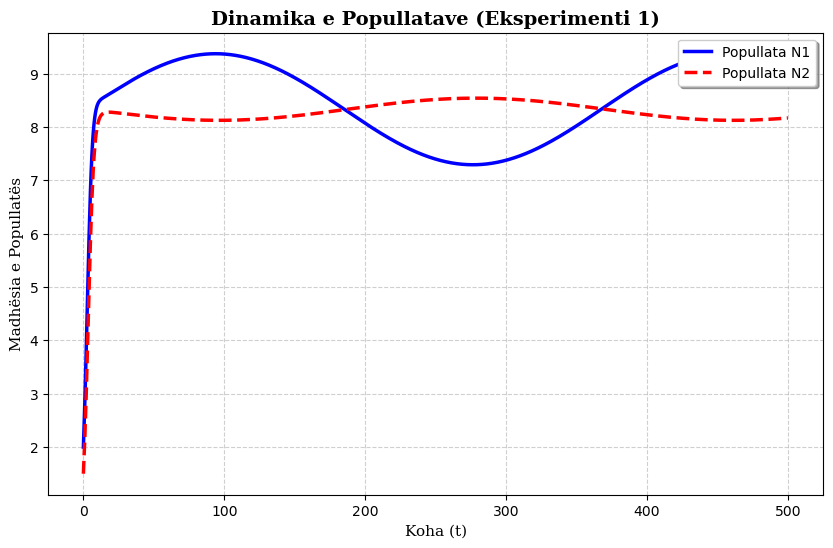

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
#Eksperimenti 1 

if not os.path.exists('figures'): os.makedirs('figures')

def model(z, t, r1, r2, a12, a21, K1_0, K2_0, amp):
    N1, N2 = z
    K1 = K1_0 * (1 + amp * np.sin(2 * np.pi * t / 365))
    dN1 = r1 * N1 * (1 - (N1 + a12 * N2) / K1)
    dN2 = r2 * N2 * (1 - (N2 + a21 * N1) / K2_0)
    return [dN1, dN2]

t = np.linspace(0, 500, 1000)
z = [2.0, 1.5]
params = (0.5, 0.5, 0.2, 0.2, 10, 10, 0.1)

res = [z]
for i in range(len(t)-1):
    dt = t[i+1] - t[i]
    d = model(res[-1], t[i], *params)
    next_z = [max(0, res[-1][j] + d[j]*dt) for j in range(2)]
    res.append(next_z)

# --- Grafiku i Stilizuar ---
plt.figure(figsize=(10, 6), dpi=100)
res_arr = np.array(res)
plt.plot(t, res_arr[:, 0], label='Popullata N1', color='blue', linewidth=2.5)
plt.plot(t, res_arr[:, 1], label='Popullata N2', color='red', linewidth=2.5, linestyle='--')

plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Dinamika e Popullatave (Eksperimenti 1)', fontsize=14, fontweight='bold', family='serif')
plt.xlabel('Koha (t)', fontsize=11, family='serif')
plt.ylabel('Madhësia e Popullatës', fontsize=11, family='serif')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.savefig('figures/eksperimenti_1.png')
plt.show()